# 02 — Fitting a non-normalized, more realistic spectrum

A key strength of kinextract is that it does **not** require a pre-normalized spectrum.
Setting `fit_continuum=True` (default `False`) tells kinextract to co-fit a smooth
continuum baseline alongside the LOSVD, so you can pass raw flux-calibrated spectra directly. 
A penalized-B-spline continuum is folded directly into the same single optimization as 
the LOSVD and template weights (see `kinextract.joint`).

This notebook builds a synthetic galaxy spectrum from a **known linear combination of
templates**, convolved with a known Gaussian LOSVD, multiplied by a synthetic galaxy
continuum, then fits it back with a larger template subgrid the same way notebook 03
fits real MUSE data: the generating templates are a known subset of the fitting
templates (no template mismatch), with real spectral complexity and a known ground truth.

**`TEMPLATE_SOURCE` (Section 1)** picks which real-world template family to draw from,
for both the mock's known "true" generating population and the fitting subgrid:
- `"emiles"` (default): kinextract's own bundled E-MILES SSP grid (smooth,
  physically-continuous population models -- see `kinextract.templates.pack_templates_to_npz`).
- `"muse"`: the individual real stars in `examples/data/muse/` (the library
  notebook 03 used before switching to E-MILES) -- idiosyncratic real spectra,
  closer to fitting an actual observed galaxy with a real stellar library.

**Key FitConfig option:** `fit_continuum = True`  (default `False`)

Note: continuum-cofit fits like this one don't yet support
`LOSVDErrorEstimator.laplace_covariance`/`bias_correction` (see Section 6) -- only
`residual_bootstrap`. If you need Laplace or bias-corrected error bars, pre-normalize
the spectrum once (e.g. via the standalone
`kinextract.continuum.asymmetric_least_squares_continuum` utility -- see
`examples/notebooks/06_prenormalized_workflow.ipynb`) and fit with
`fit_continuum=False` instead.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite

## 1. Load a few templates as the known "generating" population

Two old, moderate-metallicity templates stand in for the true stellar population at
this position -- a dominant near-solar-metallicity component plus an older, slightly
metal-poor minor one, in a known ratio (`TRUE_WEIGHTS`). Both are members of the
larger fitting subgrid built in Section 3 -- the whole point of this design, matching
notebook 03's real-data workflow: the fit has to find the right combination on its own.
Set `TEMPLATE_SOURCE` below to switch between the two supported template families.

In [2]:
# ── Which real-world template family to draw from (see Section 1 markdown) ────
# NOTE: The current version of this notebook doesn't work well with the MUSE templates. It will be fixed in a future update.
TEMPLATE_SOURCE = "emiles"  # or "muse"

WAVEMIN, STEP, N_PIX = 4750.0, 1.25, 3681
wavelength = WAVEMIN + np.arange(N_PIX) * STEP

if TEMPLATE_SOURCE == "emiles":
    from kinextract.templates import load_packed_templates

    # kinextract's own bundled E-MILES grid -- built directly from the MILES
    # project's own public FITS distribution (see
    # kinextract.templates.pack_templates_to_npz), not derived from pPXF's own
    # bundled grid (its license prohibits redistribution).
    EMILES_NPZ = str(Path('..') / 'data' / 'emiles' / 'kinextract_emiles_grid.npz')
    _emiles_wave, _emiles_flux, _emiles_meta = load_packed_templates(EMILES_NPZ)
    EMILES_FWHM_AT_CAII_A = 2.51  # Vazdekis et al. 2016 -- fixed library property

    def load_ssp(age_gyr: float, metal: float) -> np.ndarray:
        """One E-MILES SSP, resampled onto the MUSE grid, median-normalized to ~1."""
        idx = next(i for i, (a, m) in enumerate(zip(_emiles_meta["ages"], _emiles_meta["metals"]))
                   if np.isclose(a, age_gyr, atol=1e-3) and np.isclose(m, metal, atol=1e-3))
        on_grid = np.interp(wavelength, _emiles_wave, _emiles_flux[:, idx])
        pos = on_grid > 0
        med = np.nanmedian(on_grid[pos]) if pos.any() else 1.0
        return on_grid / med if med > 0 else on_grid

    GEN_SELECT = [(6.5, -0.35), (14.0, 0.15)]
    TRUE_WEIGHTS = np.array([0.6, 0.4])
    GEN_LABELS = [f"age={a:.2f} Gyr, [M/H]={m:+.2f}" for a, m in GEN_SELECT]
    templates = np.array([load_ssp(a, m) for a, m in GEN_SELECT])
    print(f"E-MILES native FWHM at CaII = {EMILES_FWHM_AT_CAII_A:.2f} Å (vs MUSE's own -- no LSF correction needed)")

elif TEMPLATE_SOURCE == "muse":
    from kinextract.io import read_template_xy

    MUSE_DIR = Path('..') / 'data' / 'muse'
    GEN_STAR_NAMES = ["HD057060_av.dat", "HD200081_av.dat"]
    TRUE_WEIGHTS = np.array([0.6, 0.4])
    GEN_LABELS = [name.replace("_av.dat", "") for name in GEN_STAR_NAMES]

    def load_star(name: str) -> np.ndarray:
        """One real MUSE-library star, resampled onto the MUSE grid, median-normalized to ~1."""
        wave, flux, _err = read_template_xy(str(MUSE_DIR / name))
        on_grid = np.interp(wavelength, wave, flux)
        pos = on_grid > 0
        med = np.nanmedian(on_grid[pos]) if pos.any() else 1.0
        return on_grid / med if med > 0 else on_grid

    templates = np.array([load_star(n) for n in GEN_STAR_NAMES])

else:
    raise ValueError(f"TEMPLATE_SOURCE must be 'emiles' or 'muse', got {TEMPLATE_SOURCE!r}")

print(f"Generating templates ({TEMPLATE_SOURCE}): {GEN_LABELS}")
print(f"True mixture weights: {TRUE_WEIGHTS}")

E-MILES native FWHM at CaII = 2.51 Å (vs MUSE's own -- no LSF correction needed)
Generating templates (emiles): ['age=6.50 Gyr, [M/H]=-0.35', 'age=14.00 Gyr, [M/H]=+0.15']
True mixture weights: [0.6 0.4]


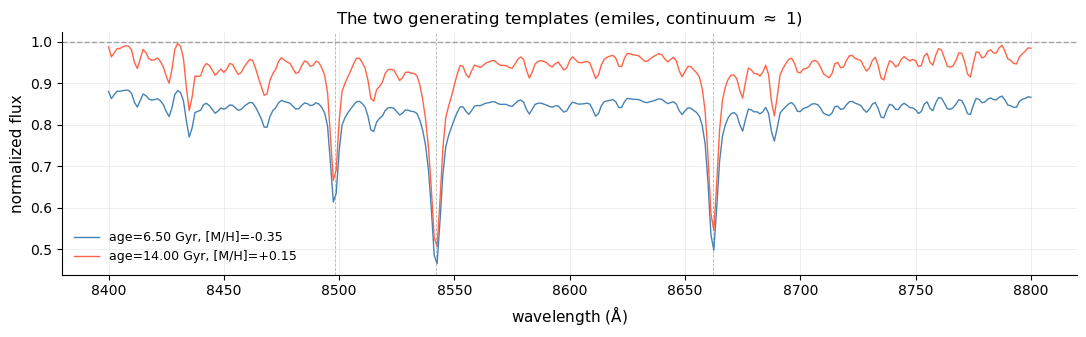

In [3]:
mask_plot = (wavelength >= 8400) & (wavelength <= 8800)

fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ['steelblue', 'tomato']
for tpl, label, c in zip(templates, GEN_LABELS, colors):
    ax.plot(wavelength[mask_plot], tpl[mask_plot], lw=1.0, color=c, label=label)
for cen in [8498.02, 8542.09, 8662.14]:
    ax.axvline(cen, lw=0.6, color='grey', ls='--', alpha=0.6)
ax.axhline(1.0, lw=1.0, color='grey', ls='--', alpha=0.7)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title(f'The two generating templates ({TEMPLATE_SOURCE}, continuum $\\approx$ 1)')
ax.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 2. Build a synthetic galaxy spectrum with a complex continuum

We combine the two generating templates with the known mixture weights (`TRUE_WEIGHTS`)
into a single population spectrum, convolve *that* with a Gaussian LOSVD (V = +80 km/s,
$\sigma$ = 60 km/s -- see the intro for why this value) -- mirroring the order the
fitting model itself uses (mix templates first, then apply one shared LOSVD
convolution) -- then multiply by a synthetic galaxy continuum: a cubic polynomial plus
a broad Gaussian hump, mimicking the overall shape of a cool-star-dominated galaxy SED.
This is the spectrum kinextract will receive: raw $\mathrm{erg/s/cm^2/\AA}$, no prior
normalization. Only the *spectrum* is synthetic here -- every template pixel is a real
spectrum from `TEMPLATE_SOURCE`.

In [4]:
WAVEFITMIN, WAVEFITMAX = 8400.0, 8800.0 
CEE, LAM_CENTER = 299792.458, 8580.0

TRUE_V     =  80.0   # km/s
TRUE_SIGMA =  140.0  # km/s

# ── Mix the SSPs, then convolve the population spectrum with the true LOSVD ──
pop_template = np.tensordot(TRUE_WEIGHTS, templates, axes=1)  # (N_PIX,)

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
RNG       = np.random.default_rng(42)
gal_norm  = ndimage_shift(gaussian_filter(pop_template, sigma_pix), +shift_pix)

# ── Galaxy continuum: cubic polynomial + broad Gaussian hump ─────────────────
# x_norm ∈ [-1, +1] across the full wavelength range.
# Produces a factor ~4 rise from blue to red with a broad hump near 7700 Å,
# roughly matching the SED of a cool-star-dominated galaxy.
# Include a small sinusoidal fringe pattern to mimic imperfect flat-fielding.

CONT_LEVEL = 12_000.0
x_norm = (wavelength - wavelength.mean()) / (0.5 * (wavelength[-1] - wavelength[0]))
slope  = 1.0 + 0.80 * x_norm + 0.5 * x_norm**2 - 0.10 * x_norm**3
hump   = 0.50 * np.exp(-0.5 * ((x_norm - 0.20) / 0.45)**2)
fringes = 0.01 * np.sin(2 * np.pi * (wavelength - wavelength[0]) / 50.0)
cont   = CONT_LEVEL * (slope + hump + fringes)

gal   = gal_norm * cont
NOISE = 250.0
gal  += RNG.normal(0.0, NOISE, N_PIX)
errs  = np.full(N_PIX, NOISE)

cat_mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
print(f"Galaxy continuum range:  {cont.min():.0f} - {cont.max():.0f}  erg/s/cm^2/angstrom$")
print(f"S/N in fit window:       "
      f"{cont[cat_mask].min() / NOISE:.0f} - {cont[cat_mask].max() / NOISE:.0f}")

# ── Save spectrum to a temp directory. Templates are NOT written here -- we fit ────
# with the full fitting subgrid built in Section 3 below, the same way
# notebook 03 fits real MUSE data with its full template library.
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_cont_'))
spec_path = tmpdir / 'mock_cont.spec'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX + 1), gal, errs]),
           fmt='%6d  %14.4f  %14.4f')
print(f"Spectrum written to {spec_path}")

Galaxy continuum range:  9162 - 27636  erg/s/cm^2/angstrom$
S/N in fit window:       94 - 100
Spectrum written to /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_cont_xjrsu10g/mock_cont.spec


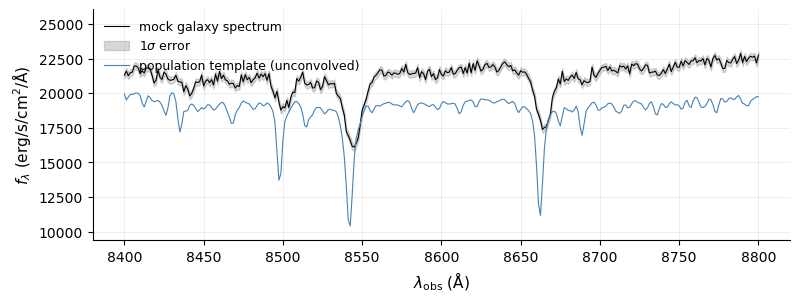

In [5]:
plt.figure(figsize=(9, 3))
plot_template = pop_template * np.median(gal[(wavelength >= 8000) & (wavelength <= 9000)])
plt.plot(wavelength[mask_plot], gal[mask_plot], lw=0.8, color='black', label='mock galaxy spectrum')
plt.fill_between(wavelength[mask_plot], gal[mask_plot] - errs[mask_plot], gal[mask_plot] + errs[mask_plot], color='grey', alpha=0.3, label=r'$1\sigma$ error')
plt.plot(wavelength[mask_plot], plot_template[mask_plot], lw=0.8, color='steelblue', label='population template (unconvolved)')
plt.xlabel(r'$\lambda_\mathrm{obs}$ ($\mathrm{\AA}$)')
plt.ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')
plt.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)

plt.ylim(0.9 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].min(), 
                1.3 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].max());

## 3. Fit with `fit_continuum = True`, using a larger fitting subgrid

Setting `fit_continuum=True` tells kinextract to estimate and remove the smooth
continuum inside the fitting loop (via `kinextract.joint`). The galaxy spectrum passed
in has raw $\mathrm{erg/s/cm^2/\AA}$ with the complex continuum intact — no
pre-normalization is needed.

We fit with a *larger* subgrid than the 2 templates that generated the mock -- for
`TEMPLATE_SOURCE = "emiles"`, a curated 20-SSP subgrid (old, moderate-to-high
metallicity populations, selected directly from kinextract's own bundled grid via
`template_npz_file`/`template_npz_select` -- no file-writing needed); for `"muse"`,
the full 35-star real MUSE library (`template_list_file`/`template_dir`). Either way
the fit has to find the right combination on its own, exactly as it would on real data.

In [6]:
# ── Build the fitting-subgrid template_kwargs for whichever TEMPLATE_SOURCE ──
if TEMPLATE_SOURCE == "emiles":
    # Curated 20-SSP subgrid (old, moderate-to-high metallicity populations --
    # physically appropriate for an early-type/bulge-dominated target, and the
    # same subgrid validated in the stress-test log), selected directly from
    # kinextract's own bundled grid -- no file-writing dance needed (see
    # FitConfig.template_npz_file/template_npz_select).
    FIT_AGES_GYR = [3.0, 4.5, 6.5, 9.5, 14.0]
    FIT_METALS = [-0.35, -0.25, 0.06, 0.15]
    TEMPLATE_SELECT = [(age, metal) for age in FIT_AGES_GYR for metal in FIT_METALS]
    template_kwargs = dict(template_npz_file=EMILES_NPZ, template_npz_select=TEMPLATE_SELECT)
    print(f"{len(TEMPLATE_SELECT)} E-MILES templates selected for fitting "
          f"(ages {FIT_AGES_GYR} Gyr x metallicities {FIT_METALS})")

elif TEMPLATE_SOURCE == "muse":
    # Fit with the full 35-star real MUSE library -- includes both generating
    # stars (GEN_STAR_NAMES) plus 33 others the fit has to weight down on its own.
    template_kwargs = dict(template_list_file=str(MUSE_DIR / "Tlist"), template_dir=str(MUSE_DIR))
    print("35 real MUSE stellar templates selected for fitting (includes the 2 generating stars)")

VRANGE = max(300.0, 3.5 * TRUE_SIGMA)

cfg = FitConfig(
    **template_kwargs,
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    n_losvd_bins        = 89,
    zgal                = 0.0,
    fit_continuum       = True,          # <-- key option
    use_spectrum_errors = True,
    xlam_auto           = True,          # xlam_criterion/xlam_discrepancy_nsigma left at their
                                          # package defaults ('discrepancy'/0.3).
    xlam_max_peaks      = 1,
    losvd_vmin          = -VRANGE,       # km/s 
    losvd_vmax          = +VRANGE,       # km/s
    sigl                = 100.0,
    joint_n_sigl0_iter  = 1,
    clean               = True,
    # n_losvd_bins/map_ftol left at their package defaults (89 / 1e-8). At
    # 89 bins this scenario's selected xlam lands right at the discrepancy
    # search's unimodality boundary (~1e7); map_maxiter raised 10000 ->
    # 20000 for headroom at that extreme regularization strength.
    map_maxiter         = 20000,
    print_every         = 999999,
)

fit = run_spectral_fit(cfg, gal_file=str(spec_path))
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chisquared_reduced = {out['chi2_red']:.3f}")
print(f"xlam chosen = {st.xlam:.1f}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

20 E-MILES templates selected for fitting (ages [3.0, 4.5, 6.5, 9.5, 14.0] Gyr x metallicities [-0.35, -0.25, 0.06, 0.15])
chisquared_reduced = 1.024
xlam chosen = 10000000.0
success     : True


## 4. Extract GH moments from the recovered LOSVD

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"Recovered:  V = {gh['vherm']:+.1f}  sigma = {gh['sherm']:.1f}  "
      f"h3 = {gh['h3']:+.4f}  h4 = {gh['h4']:+.4f}")
print(f"Truth:      V = {TRUE_V:+.1f}  sigma = {TRUE_SIGMA:.1f}")

Recovered:  V = +78.4  sigma = 141.2  h3 = -0.0254  h4 = -0.0156
Truth:      V = +80.0  sigma = 140.0


## 5. Diagnostic plots

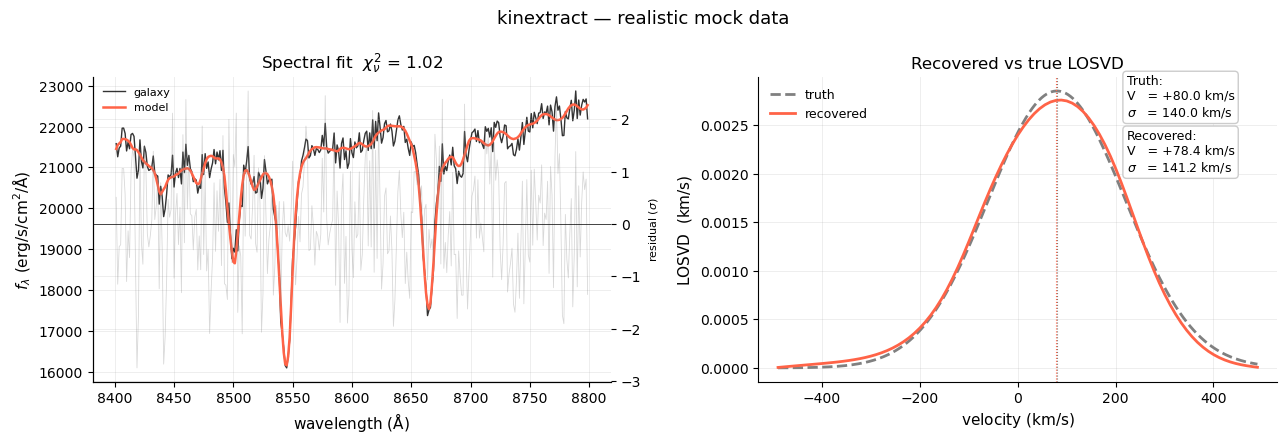

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — realistic mock data', fontsize=13)

# ── Panel 1: normalized residual ─────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.3)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')

ax.set_title(r'Spectral fit  $\chi^2_\nu$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
v_true = np.linspace(cfg.losvd_vmin, cfg.losvd_vmax, 401)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= trapezoid(b_true, v_true)
b_rec   = b / trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,       lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'],  lw=0.8, color='tomato', ls=':')


ax.text(0.71, 0.86,
        f"Truth:\n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.text(0.71, 0.68,
        f"Recovered:\n"
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel(r'velocity ($\mathrm{km/s}$)')
ax.set_ylabel(r'LOSVD  ($\mathrm{km/s}$)')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin-40, cfg.losvd_vmax+40)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated via **residual bootstrap**: resample fit residuals into synthetic spectra and refit each through the same pipeline (here, `kinextract.joint`, at the main fit's own converged xlam/sigl0/v_center) -> an independent, frequentist estimate of the LOSVD's scatter. Slower than a closed-form approximation since each of `N_BOOT` replicates is a full refit, but the only supported method for continuum-cofit fits: `laplace_covariance`/`bias_correction` don't yet understand the joint method's parameter layout and raise `NotImplementedError`.

In [9]:
from kinextract import LOSVDErrorEstimator

n_bootstrap = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
boot    = est.residual_bootstrap(n_bootstrap=n_bootstrap, n_jobs=4)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Bootstrap uncertainties:")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=4)...
[LOSVDErrors] Using 4 worker threads
[LOSVDErrors] Bootstrap 5/50 (4s elapsed)
[LOSVDErrors] Bootstrap 10/50 (6s elapsed)
[LOSVDErrors] Bootstrap 15/50 (8s elapsed)
[LOSVDErrors] Bootstrap 20/50 (10s elapsed)
[LOSVDErrors] Bootstrap 25/50 (13s elapsed)
[LOSVDErrors] Bootstrap 30/50 (15s elapsed)
[LOSVDErrors] Bootstrap 35/50 (18s elapsed)
[LOSVDErrors] Bootstrap 40/50 (21s elapsed)
[LOSVDErrors] Bootstrap 45/50 (23s elapsed)
[LOSVDErrors] Bootstrap 50/50 (25s elapsed)
[LOSVDErrors] Bootstrap done in 24.7s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +78.43 km/s ± 3.29
    σ    = 141.23 km/s ± 3.42
    h3   = -0.0254 ± 0.0225
    h4   = -0.0156 ± 0.0219
  LOSVD moments (for reference):
    V    = +70.36 km/s ± 5.35
    σ    = 141.84 km/s ± 5.50

  Bootstrap: 50 successful / 50 total replicates

Bootstrap uncertainties:
  V     = +78.43 km/s ± 3.29
  σ     = +1

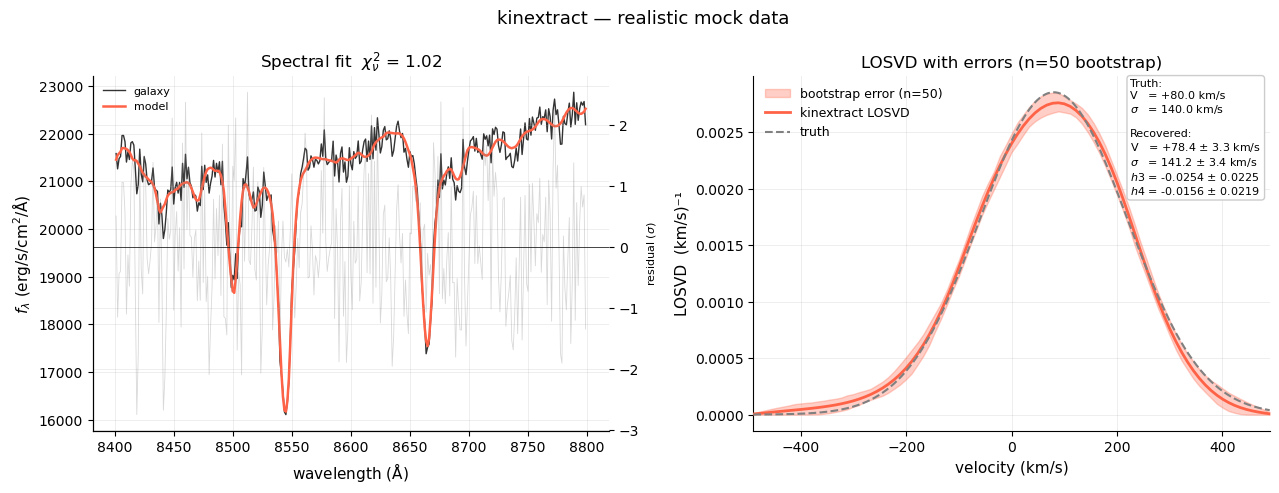

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('kinextract — realistic mock data', fontsize=13)

# --- spectral fit ---
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato',    label='model',  zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.3)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')
ax.set_title(r'Spectral fit  $\chi^2_\nu$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# --- LOSVD with bootstrap errors ---
ax = axes[1]
b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={n_bootstrap})')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='kinextract LOSVD')
ax.plot(v_true, b_true, lw=1.5, color='grey', ls='--', label='truth', zorder=5)

ax.text(0.73, 0.66,
        f"Truth:           \n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s\n\n"
        f"Recovered:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'LOSVD with errors (n={n_bootstrap} bootstrap)')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()